In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


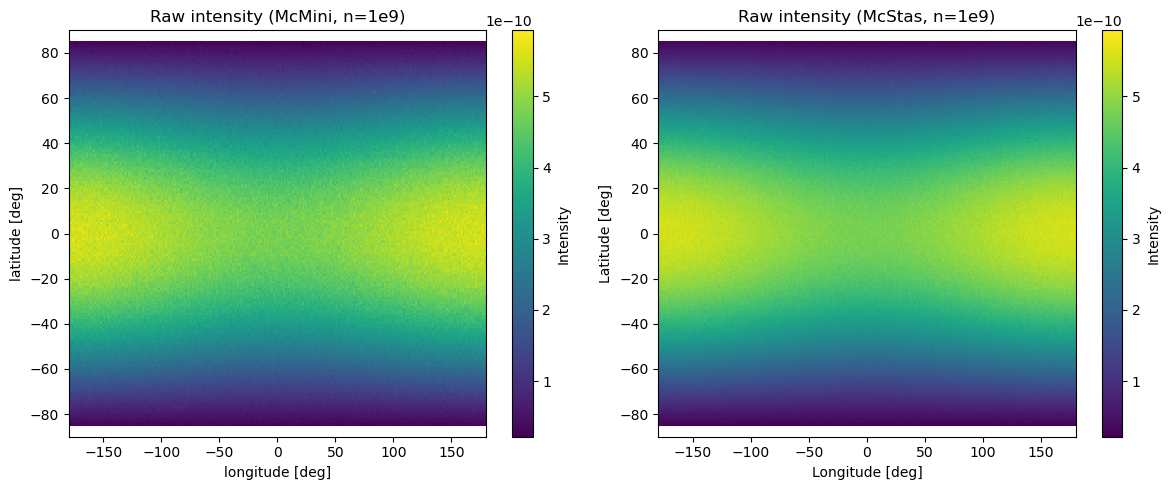

Total raw intensity (mcmini, n=1e9) = 1.957922e-05
Total raw intensity (McStas, n=1e9) = 1.958273e-05
Ratio of total raw intensities (mini/mcstas) = 9.998209e-01


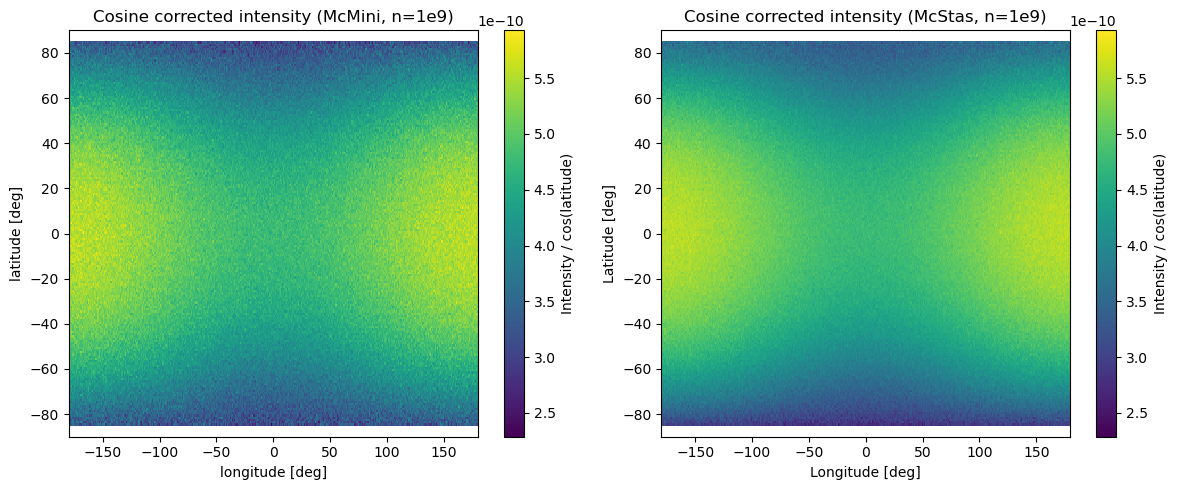

Total cosine corrected intensity (mcmini, n=1e9) = 2.766574e-05
Total cosine corrected intensity (McStas, n=1e9) = 2.767145e-05
Ratio of total cosine corrected intensities (mini/mcstas) = 9.997937e-01


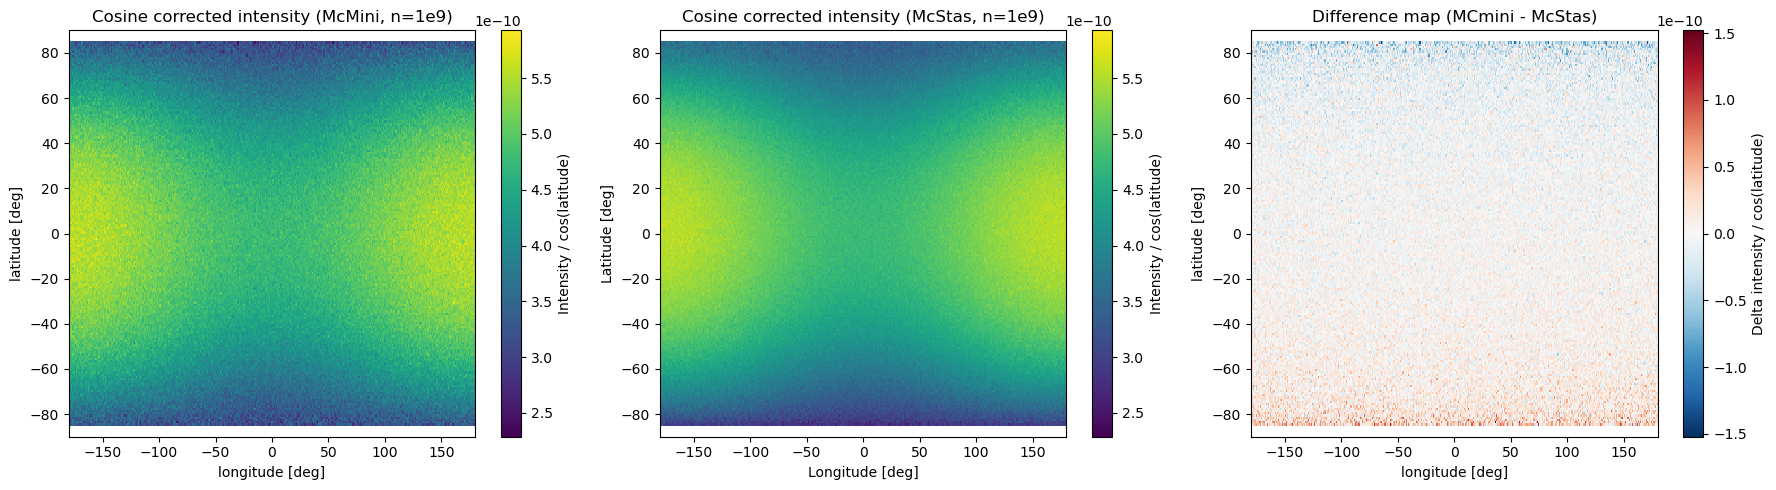

Mean residual for cosine-corrected difference map: -9.328943e-14
Mean absolute residual (cosine-corrected):         1.399019e-11
RMS residual (cosine-corrected):                   1.867373e-11
Mean pull (cosine-corrected):                      -1.522858e-02
Pull std (cosine-corrected):                       1.094898e+00
Reduced chi^2 (cosine-corrected):                  1.199033e+00


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_91752/3672379329.py:161: RuntimeWarning: Mean of empty slice
  lat_residual_mean = np.nanmean(diff_corr_masked, axis=1)
/opt/homebrew/Caskroom/miniconda/base/envs/mcstas/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


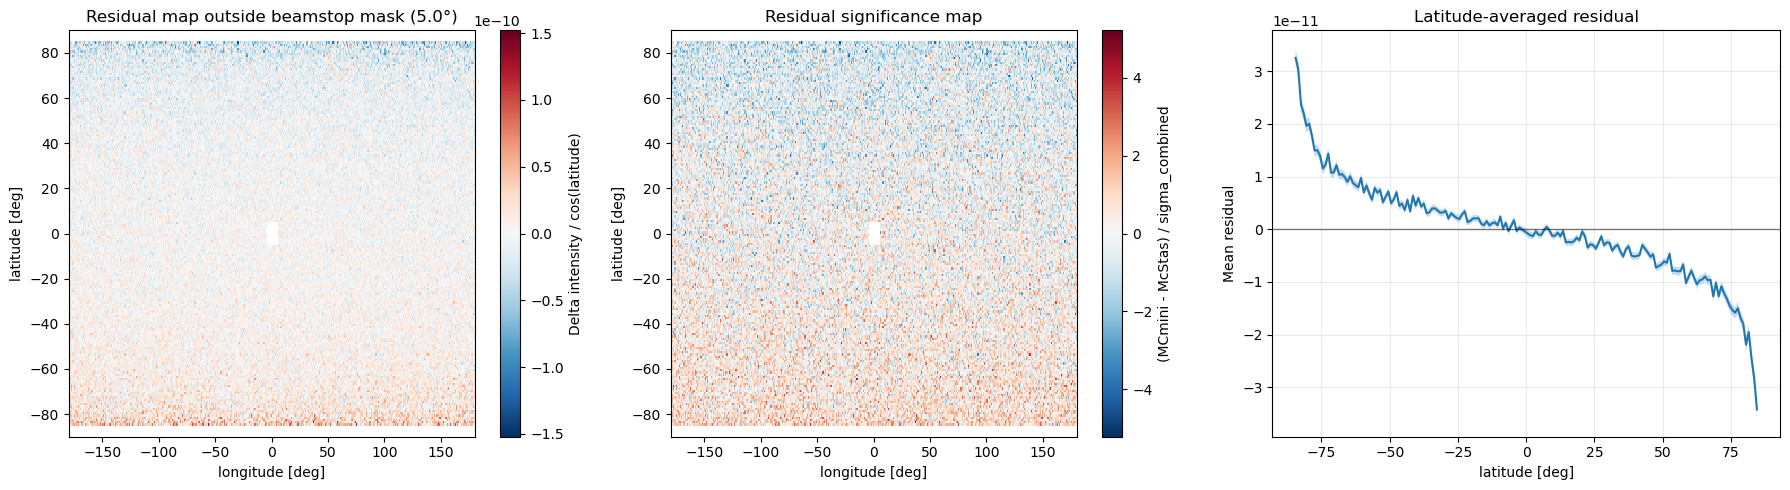

Beamstop diagnostic mask: excluding |lon| < 5.0 deg and |lat| < 5.0 deg
Residual RMS outside mask: 1.868342e-11
Mean |significance| outside mask: 0.874657


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_91752/3672379329.py:198: RuntimeWarning: Mean of empty slice
  lat_residual_mean_raw = np.nanmean(diff_raw_masked, axis=1)


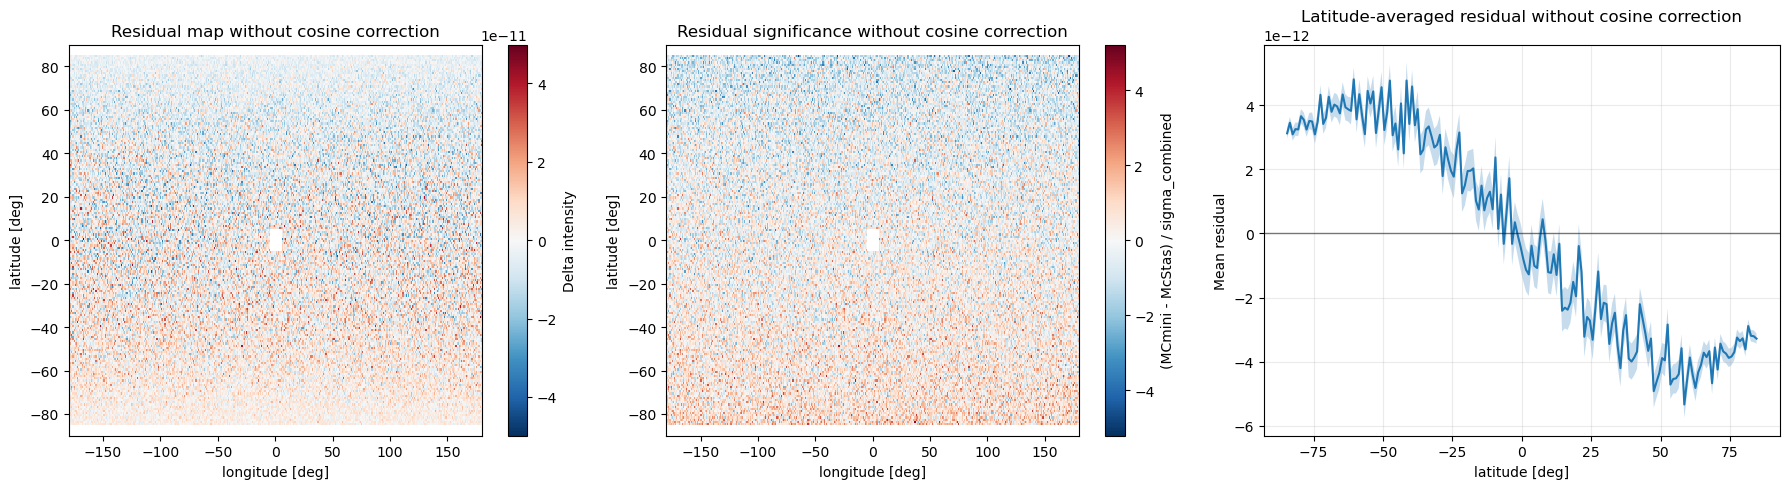

Raw residual RMS outside mask: 1.030657e-11
Raw mean |significance| outside mask: 0.874657
Alignment scan on raw maps (lower RMS is better):
  lon_shift_+1 1.028950e-11
  lon_flip     1.029095e-11
  lat_flip     1.029460e-11
  none         1.030657e-11
  lon_shift_-1 1.032396e-11
  lat_shift_-1 1.032854e-11
  lat_shift_+1 1.359101e-11
Best candidate: lon_shift_+1 (RMS=1.028950e-11)


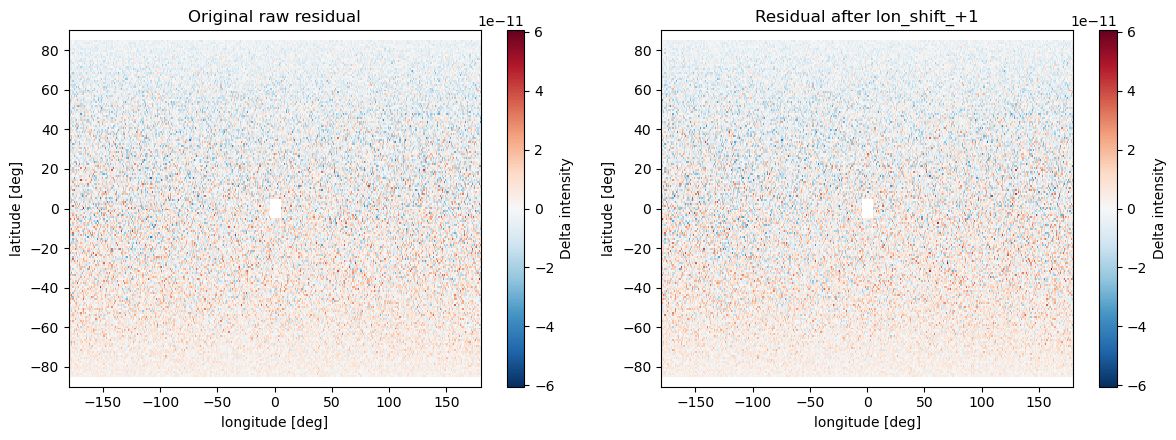

Total intensity (mcmini, n=1e9) = 1.962808814634965e-05
Total intensity (McStas, n=1e9) = 1.9632054364761775e-05
Ratio of total intensities (mini/mcstas) = 0.999797972319227
Using equator bin index: 89, latitude center: -0.50 deg


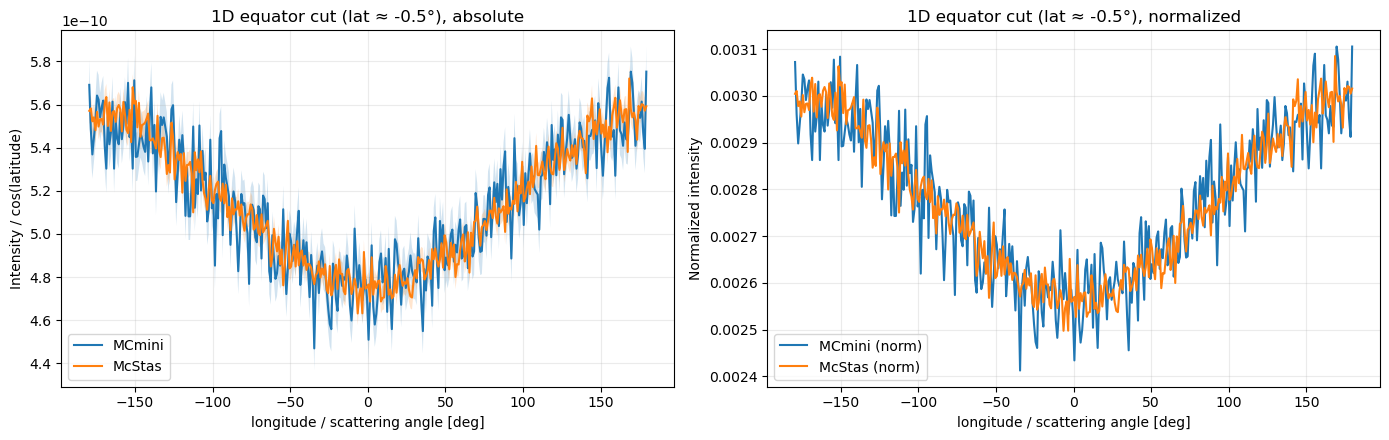

Using meridian bin index: 179, longitude center: -0.50 deg


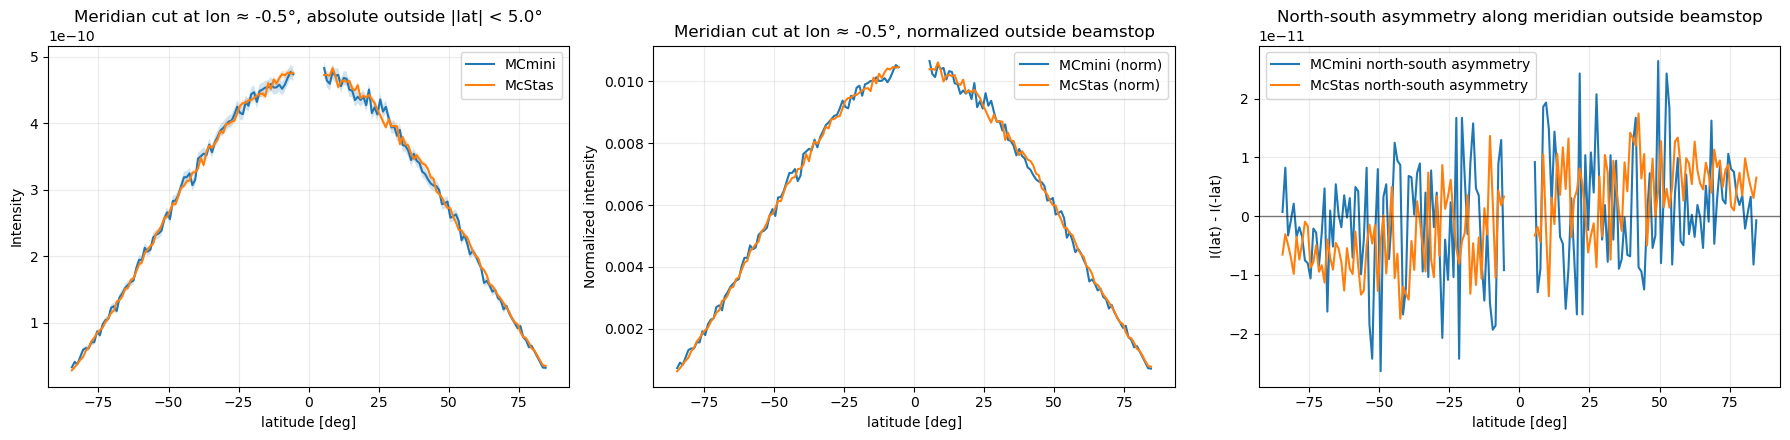

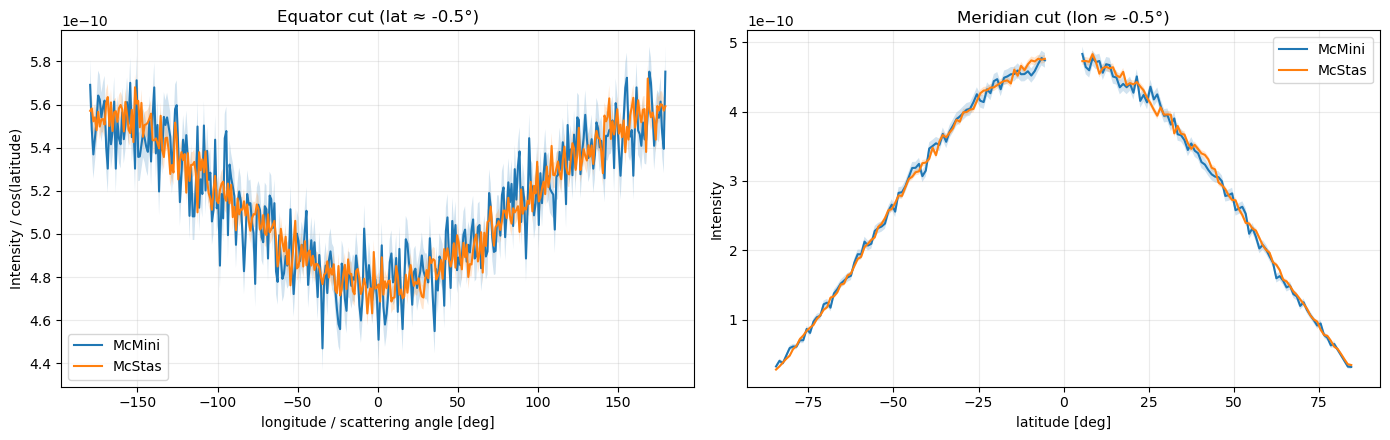

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_91752/3672379329.py:405: RuntimeWarning: Mean of empty slice
  mini_mer_band_raw = np.nanmean(H_mini_raw[:, band_mask], axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_91752/3672379329.py:406: RuntimeWarning: Mean of empty slice
  mcstas_mer_band_raw = np.nanmean(Hmc_raw[:, band_mask], axis=1)


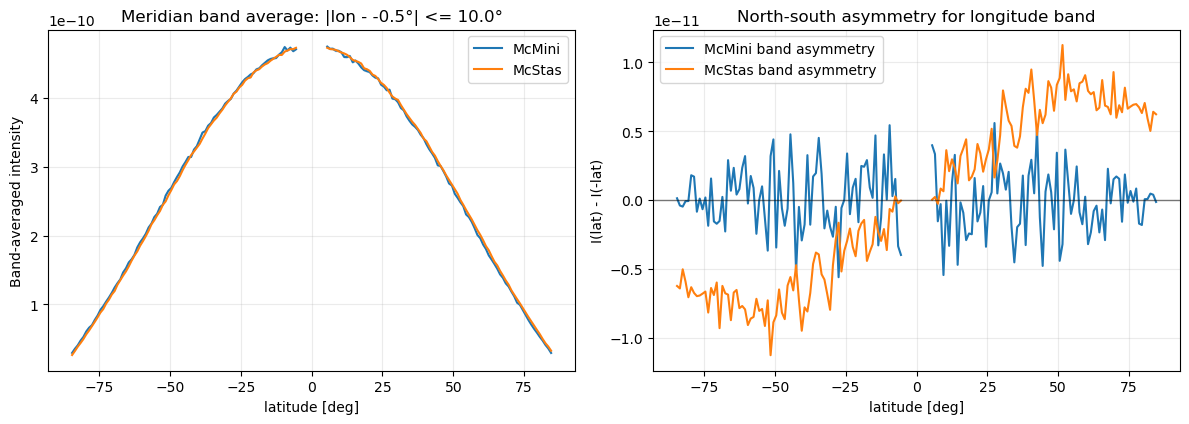

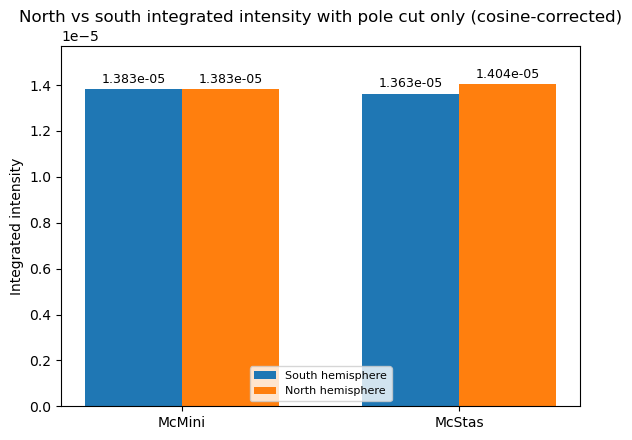

McMini north integrated intensity with pole cut only (corrected):         1.383150e-05
McMini south integrated intensity with pole cut only (corrected):         1.383425e-05
McMini hemisphere asymmetry (N-S)/(N+S):  -9.944478e-05
McStas north integrated intensity with pole cut only (corrected):         1.404191e-05
McStas south integrated intensity with pole cut only (corrected):         1.362954e-05
McStas hemisphere asymmetry (N-S)/(N+S):  1.490263e-02
Total integrated intensity for McStas full corrected map (with poles cut): 2.767145e-05
Total integrated intensity for McMini full corrected map (with poles cut): 2.766574e-05
Intesity ratio of total integrated intensities (mini/mcstas) for full corrected maps: 9.997937e-01
Northern hemisphere integrated intensity for McStas full corrected map (0° <= lat <= 85°): 1.404191e-05
Northern hemisphere integrated intensity for McMini full corrected map (0° <= lat <= 85°): 1.383150e-05
Southern hemisphere integrated intensity for McStas full c

In [6]:
pole_cut_deg = 5.0

def read_mcmini_n_history(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("# n_history="):
                return int(line.split("=", 1)[1].strip())
    raise ValueError(f"Could not find n_history header in {path}")

lat_centers = np.linspace(-89.5, 89.5, 180)
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]  # shape (180, 1)
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg (last {pole_cut_deg:.1f} deg near each pole)")

# mcmini data
# mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_sphere_validation/sphere_1cm_direconly_mcmini/sphere_1cm_multiple_scatter_3.csv")
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/cyl_r5mmh2cm_mcmini/solid_cylinder_multiple_scatter.csv")

nx, ny = 360, 180
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H_mini = col_counts.reshape((ny, nx))  # (latitude bins, longitude bins)
if binned_data.shape[1] >= 4:
    sigma_mini = binned_data[:, 3].reshape((ny, nx))
else:
    mcmini_n_history = read_mcmini_n_history(mcmini_binned_path)
    sigma_mini = np.sqrt(np.maximum(H_mini * mcmini_n_history, 0.0)) / mcmini_n_history
H_mini_raw = H_mini[0:180, :]
sigma_mini_raw = sigma_mini[0:180, :]
H_mini_corr = H_mini / np.where(cos_correction == 0, np.nan, cos_correction)  # avoid divide by zero
sigma_mini_corr = sigma_mini / np.where(cos_correction == 0, np.nan, cos_correction)
H_mini_corr = H_mini_corr[0:180, :]
H_mini_corr = np.where(pole_mask[:, np.newaxis], H_mini_corr, np.nan)
H_mini_raw = np.where(pole_mask[:, np.newaxis], H_mini_raw, np.nan)
sigma_mini_raw = np.where(pole_mask[:, np.newaxis], sigma_mini_raw, np.nan)
sigma_mini_corr = sigma_mini_corr[0:180, :]
sigma_mini_corr = np.where(pole_mask[:, np.newaxis], sigma_mini_corr, np.nan)

# mcstas data 
# sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_sphere_validation/sphere_1cm_flatmon_1e9")[1]  # adjust index if needed
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/cyl_r5mmh2cm_mcstas")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
hits_err = sphere_mon.Error
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
Hmc_err = hits_err
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T
Hmc_raw = Hmc[0:180, :]
sigma_mcstas_raw = Hmc_err[0:180, :]
Hmc_corr = Hmc / np.where(cos_correction == 0, np.nan, cos_correction)  # apply same correction to McStas data
sigma_mcstas_corr = Hmc_err / np.where(cos_correction == 0, np.nan, cos_correction)
Hmc_corr = Hmc_corr[0:180, :]
Hmc_corr = np.where(pole_mask[:, np.newaxis], Hmc_corr, np.nan)
Hmc_raw = np.where(pole_mask[:, np.newaxis], Hmc_raw, np.nan)
sigma_mcstas_raw = np.where(pole_mask[:, np.newaxis], sigma_mcstas_raw, np.nan)
sigma_mcstas_corr = sigma_mcstas_corr[0:180, :]
sigma_mcstas_corr = np.where(pole_mask[:, np.newaxis], sigma_mcstas_corr, np.nan)

beamstop_mask_deg = 5.0

# plot raw side by side without difference map
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
extent = [-180, 180, -90, 90]
vmin = min(np.nanmin(H_mini_raw), np.nanmin(Hmc_raw))
vmax = max(np.nanmax(H_mini_raw), np.nanmax(Hmc_raw))
axs[0].imshow(H_mini_raw, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Raw intensity (McMini, n=1e9)")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Intensity")
axs[1].imshow(Hmc_raw, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[1].set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
axs[1].set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
axs[1].set_title("Raw intensity (McStas, n=1e9)")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Intensity")
plt.tight_layout()
plt.show()
#p rint integrated intensity in each raw map   
print(f"Total raw intensity (mcmini, n=1e9) = {np.nansum(H_mini_raw):.6e}")
print(f"Total raw intensity (McStas, n=1e9) = {np.nansum(Hmc_raw):.6e}")
print(f"Ratio of total raw intensities (mini/mcstas) = {np.nansum(H_mini_raw) / np.nansum(Hmc_raw):.6e}")

# plot corrected side by side without difference map
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
extent = [-180, 180, -90, 90]
vmin = min(np.nanmin(H_mini_corr), np.nanmin(Hmc_corr))
vmax = max(np.nanmax(H_mini_corr), np.nanmax(Hmc_corr))
axs[0].imshow(H_mini_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Cosine corrected intensity (McMini, n=1e9)")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Intensity / cos(latitude)")
axs[1].imshow(Hmc_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[1].set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
axs[1].set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
axs[1].set_title("Cosine corrected intensity (McStas, n=1e9)")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Intensity / cos(latitude)")
plt.tight_layout()
plt.show()
#print integrated intensity in each map
print(f"Total cosine corrected intensity (mcmini, n=1e9) = {np.nansum(H_mini_corr):.6e}")
print(f"Total cosine corrected intensity (McStas, n=1e9) = {np.nansum(Hmc_corr):.6e}")
print(f"Ratio of total cosine corrected intensities (mini/mcstas) = {np.nansum(H_mini_corr) / np.nansum(Hmc_corr):.6e}")

# plot side by side with difference map
diff_corr = H_mini_corr - Hmc_corr
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
extent = [-180, 180, -90, 90]
vmin = min(np.nanmin(H_mini_corr), np.nanmin(Hmc_corr))
vmax = max(np.nanmax(H_mini_corr), np.nanmax(Hmc_corr))
diff_absmax = np.nanmax(np.abs(diff_corr))
axs[0].imshow(H_mini_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Cosine corrected intensity (McMini, n=1e9)")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Intensity / cos(latitude)")
axs[1].imshow(Hmc_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[1].set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
axs[1].set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
axs[1].set_title("Cosine corrected intensity (McStas, n=1e9)")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Intensity / cos(latitude)")
axs[2].imshow(diff_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
axs[2].set_xlabel("longitude [deg]")
axs[2].set_ylabel("latitude [deg]")
axs[2].set_title("Difference map (MCmini - McStas)")
fig.colorbar(axs[2].images[0], ax=axs[2], label="Delta intensity / cos(latitude)")
plt.tight_layout()
plt.show()

sigma_combined_full = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
pull_full = diff_corr / np.maximum(sigma_combined_full, 1e-30)
valid_full = np.isfinite(diff_corr) & np.isfinite(pull_full)
n_valid_full = np.sum(valid_full)
mean_residual_corr = np.nanmean(diff_corr)
mae_residual_corr = np.nanmean(np.abs(diff_corr))
rms_residual_corr = np.sqrt(np.nanmean(diff_corr**2))
mean_pull_corr = np.nanmean(pull_full)
std_pull_corr = np.nanstd(pull_full)
chi2_corr = np.nansum(pull_full[valid_full]**2)
chi2_red_corr = chi2_corr / n_valid_full if n_valid_full > 0 else np.nan

print(f"Mean residual for cosine-corrected difference map: {mean_residual_corr:.6e}")
print(f"Mean absolute residual (cosine-corrected):         {mae_residual_corr:.6e}")
print(f"RMS residual (cosine-corrected):                   {rms_residual_corr:.6e}")
print(f"Mean pull (cosine-corrected):                      {mean_pull_corr:.6e}")
print(f"Pull std (cosine-corrected):                       {std_pull_corr:.6e}")
print(f"Reduced chi^2 (cosine-corrected):                  {chi2_red_corr:.6e}")

# extra diagnostics for systematic structure outside the beamstop region
sigma_combined_map = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
significance_map = diff_corr / np.maximum(sigma_combined_map, 1e-30)
lon_centers_2d = np.linspace(-179.5, 179.5, nx)[np.newaxis, :]
lat_centers_2d = lat_centers[:, np.newaxis]
beamstop_mask = (np.abs(lon_centers_2d) < beamstop_mask_deg) & (np.abs(lat_centers_2d) < beamstop_mask_deg)
diff_corr_masked = np.where(beamstop_mask, np.nan, diff_corr)
significance_map_masked = np.where(beamstop_mask, np.nan, significance_map)
lat_residual_mean = np.nanmean(diff_corr_masked, axis=1)
lat_counts = np.sum(np.isfinite(diff_corr_masked), axis=1)
lat_residual_sem = np.nanstd(diff_corr_masked, axis=1) / np.sqrt(np.maximum(lat_counts, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
raw_diff_absmax = np.nanmax(np.abs(diff_corr_masked))
sig_absmax = min(np.nanmax(np.abs(significance_map_masked)), 8.0)
axs[0].imshow(diff_corr_masked, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_diff_absmax, vmax=raw_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title(f"Residual map outside beamstop mask ({beamstop_mask_deg:.1f}°)")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity / cos(latitude)")
axs[1].imshow(significance_map_masked, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-sig_absmax, vmax=sig_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title("Residual significance map")
fig.colorbar(axs[1].images[0], ax=axs[1], label="(MCmini - McStas) / sigma_combined")
axs[2].plot(lat_centers, lat_residual_mean, lw=1.5)
axs[2].fill_between(lat_centers, lat_residual_mean - lat_residual_sem, lat_residual_mean + lat_residual_sem, alpha=0.25)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("Mean residual")
axs[2].set_title("Latitude-averaged residual")
axs[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Beamstop diagnostic mask: excluding |lon| < {beamstop_mask_deg:.1f} deg and |lat| < {beamstop_mask_deg:.1f} deg")
print(f"Residual RMS outside mask: {np.sqrt(np.nanmean(diff_corr_masked**2)):.6e}")
print(f"Mean |significance| outside mask: {np.nanmean(np.abs(significance_map_masked)):.6f}")

# same diagnostic without cosine correction
diff_raw = H_mini_raw - Hmc_raw
sigma_combined_raw = np.sqrt(sigma_mini_raw**2 + sigma_mcstas_raw**2)
significance_raw = diff_raw / np.maximum(sigma_combined_raw, 1e-30)
diff_raw_masked = np.where(beamstop_mask, np.nan, diff_raw)
significance_raw_masked = np.where(beamstop_mask, np.nan, significance_raw)
lat_residual_mean_raw = np.nanmean(diff_raw_masked, axis=1)
lat_counts_raw = np.sum(np.isfinite(diff_raw_masked), axis=1)
lat_residual_sem_raw = np.nanstd(diff_raw_masked, axis=1) / np.sqrt(np.maximum(lat_counts_raw, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
raw_diff_absmax = np.nanmax(np.abs(diff_raw_masked))
raw_sig_absmax = min(np.nanmax(np.abs(significance_raw_masked)), 8.0)
axs[0].imshow(diff_raw_masked, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_diff_absmax, vmax=raw_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Residual map without cosine correction")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity")
axs[1].imshow(significance_raw_masked, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_sig_absmax, vmax=raw_sig_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title("Residual significance without cosine correction")
fig.colorbar(axs[1].images[0], ax=axs[1], label="(MCmini - McStas) / sigma_combined")
axs[2].plot(lat_centers, lat_residual_mean_raw, lw=1.5)
axs[2].fill_between(lat_centers, lat_residual_mean_raw - lat_residual_sem_raw, lat_residual_mean_raw + lat_residual_sem_raw, alpha=0.25)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("Mean residual")
axs[2].set_title("Latitude-averaged residual without cosine correction")
axs[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Raw residual RMS outside mask: {np.sqrt(np.nanmean(diff_raw_masked**2)):.6e}")
print(f"Raw mean |significance| outside mask: {np.nanmean(np.abs(significance_raw_masked)):.6f}")

# alignment tests: flips and 1-bin shifts applied to the McStas map
def score_alignment(reference, candidate, mask):
    diff = np.where(mask, np.nan, reference - candidate)
    return np.sqrt(np.nanmean(diff**2))

alignment_candidates = {
    "none": Hmc_raw,
    "lat_flip": Hmc_raw[::-1, :],
    "lon_flip": Hmc_raw[:, ::-1],
    "lat_shift_+1": np.roll(Hmc_raw, 1, axis=0),
    "lat_shift_-1": np.roll(Hmc_raw, -1, axis=0),
    "lon_shift_+1": np.roll(Hmc_raw, 1, axis=1),
    "lon_shift_-1": np.roll(Hmc_raw, -1, axis=1),
}
alignment_scores = {name: score_alignment(H_mini_raw, candidate, beamstop_mask) for name, candidate in alignment_candidates.items()}
best_alignment = min(alignment_scores, key=alignment_scores.get)
print("Alignment scan on raw maps (lower RMS is better):")
for name in sorted(alignment_scores, key=alignment_scores.get):
    print(f"  {name:12s} {alignment_scores[name]:.6e}")
print(f"Best candidate: {best_alignment} (RMS={alignment_scores[best_alignment]:.6e})")

best_candidate = alignment_candidates[best_alignment]
best_diff = np.where(beamstop_mask, np.nan, H_mini_raw - best_candidate)
best_diff_absmax = np.nanmax(np.abs(best_diff))
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].imshow(diff_raw_masked, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-best_diff_absmax, vmax=best_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Original raw residual")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity")
axs[1].imshow(best_diff, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-best_diff_absmax, vmax=best_diff_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title(f"Residual after {best_alignment}")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Delta intensity")
plt.tight_layout()
plt.show()

#print sum of intensities
print("Total intensity (mcmini, n=1e9) =", H_mini.sum())
print("Total intensity (McStas, n=1e9) =", Hmc.sum())
ratio = H_mini.sum() / Hmc.sum()
print("Ratio of total intensities (mini/mcstas) =", ratio)


# --- 1D cut langs ækvator (latitude = 0 deg) ---

# Latitude-bin-centre for ny=180 over [-90, 90]
lat_centers = np.linspace(-89.5, 89.5, ny)

# Find bin nærmest 0 deg
eq_idx = int(np.argmin(np.abs(lat_centers - 0.0)))
eq_lat = lat_centers[eq_idx]
print(f"Using equator bin index: {eq_idx}, latitude center: {eq_lat:.2f} deg")

# Longitude-akse (spredningsvinkel i dit plot-setup)
lon_centers = np.linspace(-179.5, 179.5, nx)

# 1D profiler
mini_eq = H_mini_corr[eq_idx, :]
mcstas_eq = Hmc_corr[eq_idx, :]
mini_eq_sigma = sigma_mini_corr[eq_idx, :]
mcstas_eq_sigma = sigma_mcstas_corr[eq_idx, :]

# Normaliseret 1D (form-sammenligning)
mini_eq_norm = mini_eq / np.nansum(mini_eq)
mcstas_eq_norm = mcstas_eq / np.nansum(mcstas_eq)

# Absolut + normaliseret plot
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

# Absolut 1D cut
axs[0].plot(lon_centers, mini_eq, label="MCmini", lw=1.5)
axs[0].fill_between(lon_centers, mini_eq - mini_eq_sigma, mini_eq + mini_eq_sigma, alpha=0.2)
axs[0].plot(lon_centers, mcstas_eq, label="McStas", lw=1.5)
axs[0].fill_between(lon_centers, mcstas_eq - mcstas_eq_sigma, mcstas_eq + mcstas_eq_sigma, alpha=0.2)
axs[0].set_xlabel("longitude / scattering angle [deg]")
axs[0].set_ylabel("Intensity / cos(latitude)")
axs[0].set_title(f"1D equator cut (lat ≈ {eq_lat:.1f}°), absolute")
axs[0].legend()
axs[0].grid(alpha=0.25)

# Normaliseret 1D cut (kun form)
axs[1].plot(lon_centers, mini_eq_norm, label="MCmini (norm)", lw=1.5)
axs[1].plot(lon_centers, mcstas_eq_norm, label="McStas (norm)", lw=1.5)
axs[1].set_xlabel("longitude / scattering angle [deg]")
axs[1].set_ylabel("Normalized intensity")
axs[1].set_title(f"1D equator cut (lat ≈ {eq_lat:.1f}°), normalized")
axs[1].legend()
axs[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# --- 1D cut from south to north pole along a fixed longitude ---
meridian_lon_deg = 0.0
mer_idx = int(np.argmin(np.abs(lon_centers - meridian_lon_deg)))
mer_lon = lon_centers[mer_idx]
print(f"Using meridian bin index: {mer_idx}, longitude center: {mer_lon:.2f} deg")

mini_mer_raw = H_mini_raw[:, mer_idx]
mcstas_mer_raw = Hmc_raw[:, mer_idx]
mini_mer_sigma_raw = sigma_mini_raw[:, mer_idx]
mcstas_mer_sigma_raw = sigma_mcstas_raw[:, mer_idx]

meridian_keep_mask = np.abs(lat_centers) >= beamstop_mask_deg
mini_mer_raw_cut = np.where(meridian_keep_mask, mini_mer_raw, np.nan)
mcstas_mer_raw_cut = np.where(meridian_keep_mask, mcstas_mer_raw, np.nan)
mini_mer_sigma_raw_cut = np.where(meridian_keep_mask, mini_mer_sigma_raw, np.nan)
mcstas_mer_sigma_raw_cut = np.where(meridian_keep_mask, mcstas_mer_sigma_raw, np.nan)

mini_mer_norm = mini_mer_raw_cut / np.nansum(mini_mer_raw_cut)
mcstas_mer_norm = mcstas_mer_raw_cut / np.nansum(mcstas_mer_raw_cut)

# North-south asymmetry along the chosen meridian
mini_mer_asym = mini_mer_raw_cut - mini_mer_raw_cut[::-1]
mcstas_mer_asym = mcstas_mer_raw_cut - mcstas_mer_raw_cut[::-1]

fig, axs = plt.subplots(1, 3, figsize=(18, 4.5))
axs[0].plot(lat_centers, mini_mer_raw_cut, label="MCmini", lw=1.5)
axs[0].fill_between(lat_centers, mini_mer_raw_cut - mini_mer_sigma_raw_cut, mini_mer_raw_cut + mini_mer_sigma_raw_cut, alpha=0.2)
axs[0].plot(lat_centers, mcstas_mer_raw_cut, label="McStas", lw=1.5)
axs[0].fill_between(lat_centers, mcstas_mer_raw_cut - mcstas_mer_sigma_raw_cut, mcstas_mer_raw_cut + mcstas_mer_sigma_raw_cut, alpha=0.2)
axs[0].set_xlabel("latitude [deg]")
axs[0].set_ylabel("Intensity")
axs[0].set_title(f"Meridian cut at lon ≈ {mer_lon:.1f}°, absolute outside |lat| < {beamstop_mask_deg:.1f}°")
axs[0].legend()
axs[0].grid(alpha=0.25)

axs[1].plot(lat_centers, mini_mer_norm, label="MCmini (norm)", lw=1.5)
axs[1].plot(lat_centers, mcstas_mer_norm, label="McStas (norm)", lw=1.5)
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel("Normalized intensity")
axs[1].set_title(f"Meridian cut at lon ≈ {mer_lon:.1f}°, normalized outside beamstop")
axs[1].legend()
axs[1].grid(alpha=0.25)

axs[2].plot(lat_centers, mini_mer_asym, label="MCmini north-south asymmetry", lw=1.5)
axs[2].plot(lat_centers, mcstas_mer_asym, label="McStas north-south asymmetry", lw=1.5)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("I(lat) - I(-lat)")
axs[2].set_title("North-south asymmetry along meridian outside beamstop")
axs[2].legend()
axs[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Side-by-side comparison of equator and meridian absolute cuts
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].plot(lon_centers, mini_eq, label="McMini", lw=1.5)
axs[0].fill_between(lon_centers, mini_eq - mini_eq_sigma, mini_eq + mini_eq_sigma, alpha=0.2)
axs[0].plot(lon_centers, mcstas_eq, label="McStas", lw=1.5)
axs[0].fill_between(lon_centers, mcstas_eq - mcstas_eq_sigma, mcstas_eq + mcstas_eq_sigma, alpha=0.2)
axs[0].set_xlabel("longitude / scattering angle [deg]")
axs[0].set_ylabel("Intensity / cos(latitude)")
axs[0].set_title(f"Equator cut (lat ≈ {eq_lat:.1f}°)")
axs[0].legend()
axs[0].grid(alpha=0.25)

axs[1].plot(lat_centers, mini_mer_raw_cut, label="McMini", lw=1.5)
axs[1].fill_between(lat_centers, mini_mer_raw_cut - mini_mer_sigma_raw_cut, mini_mer_raw_cut + mini_mer_sigma_raw_cut, alpha=0.2)
axs[1].plot(lat_centers, mcstas_mer_raw_cut, label="McStas", lw=1.5)
axs[1].fill_between(lat_centers, mcstas_mer_raw_cut - mcstas_mer_sigma_raw_cut, mcstas_mer_raw_cut + mcstas_mer_sigma_raw_cut, alpha=0.2)
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel("Intensity")
axs[1].set_title(f"Meridian cut (lon ≈ {mer_lon:.1f}°)")
axs[1].legend()
axs[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Band-averaged north-south asymmetry around the chosen meridian to reduce noise
meridian_band_halfwidth_deg = 10.0
band_mask = np.abs(lon_centers - mer_lon) <= meridian_band_halfwidth_deg
mini_mer_band_raw = np.nanmean(H_mini_raw[:, band_mask], axis=1)
mcstas_mer_band_raw = np.nanmean(Hmc_raw[:, band_mask], axis=1)
mini_mer_band_sigma = np.sqrt(np.nansum(sigma_mini_raw[:, band_mask]**2, axis=1)) / np.maximum(np.sum(np.isfinite(sigma_mini_raw[:, band_mask]), axis=1), 1)
mcstas_mer_band_sigma = np.sqrt(np.nansum(sigma_mcstas_raw[:, band_mask]**2, axis=1)) / np.maximum(np.sum(np.isfinite(sigma_mcstas_raw[:, band_mask]), axis=1), 1)
mini_mer_band_raw_cut = np.where(meridian_keep_mask, mini_mer_band_raw, np.nan)
mcstas_mer_band_raw_cut = np.where(meridian_keep_mask, mcstas_mer_band_raw, np.nan)
mini_mer_band_sigma_cut = np.where(meridian_keep_mask, mini_mer_band_sigma, np.nan)
mcstas_mer_band_sigma_cut = np.where(meridian_keep_mask, mcstas_mer_band_sigma, np.nan)
mini_mer_band_asym = mini_mer_band_raw_cut - mini_mer_band_raw_cut[::-1]
mcstas_mer_band_asym = mcstas_mer_band_raw_cut - mcstas_mer_band_raw_cut[::-1]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(lat_centers, mini_mer_band_raw_cut, label="McMini", lw=1.5)
axs[0].fill_between(lat_centers, mini_mer_band_raw_cut - mini_mer_band_sigma_cut, mini_mer_band_raw_cut + mini_mer_band_sigma_cut, alpha=0.2)
axs[0].plot(lat_centers, mcstas_mer_band_raw_cut, label="McStas", lw=1.5)
axs[0].fill_between(lat_centers, mcstas_mer_band_raw_cut - mcstas_mer_band_sigma_cut, mcstas_mer_band_raw_cut + mcstas_mer_band_sigma_cut, alpha=0.2)
axs[0].set_xlabel("latitude [deg]")
axs[0].set_ylabel("Band-averaged intensity")
axs[0].set_title(f"Meridian band average: |lon - {mer_lon:.1f}°| <= {meridian_band_halfwidth_deg:.1f}°")
axs[0].legend()
axs[0].grid(alpha=0.25)
axs[1].plot(lat_centers, mini_mer_band_asym, label="McMini band asymmetry", lw=1.5)
axs[1].plot(lat_centers, mcstas_mer_band_asym, label="McStas band asymmetry", lw=1.5)
axs[1].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel("I(lat) - I(-lat)")
axs[1].set_title("North-south asymmetry for longitude band")
axs[1].legend()
axs[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Hemisphere-integrated north-vs-south comparison with pole cut only.
# Use cosine-corrected maps so the integral is less sensitive to latitude-bin area.
# Keep the equatorial band and exclude only the last pole_cut_deg near each pole.
south_mask = lat_centers < 0
north_mask = lat_centers >= 0
mini_south = np.nansum(H_mini_corr[south_mask, :])
mini_north = np.nansum(H_mini_corr[north_mask, :])
mcstas_south = np.nansum(Hmc_corr[south_mask, :])
mcstas_north = np.nansum(Hmc_corr[north_mask, :])
mini_hemi_asym = (mini_north - mini_south) / (mini_north + mini_south)
mcstas_hemi_asym = (mcstas_north - mcstas_south) / (mcstas_north + mcstas_south)

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["McMini", "McStas"]
north_vals = [mini_north, mcstas_north]
south_vals = [mini_south, mcstas_south]
x = np.arange(len(labels))
w = 0.35
south_bars = ax.bar(x - w/2, south_vals, width=w, label="South hemisphere")
north_bars = ax.bar(x + w/2, north_vals, width=w, label="North hemisphere")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Integrated intensity")
ax.set_title(f"North vs south integrated intensity with pole cut only (cosine-corrected)")
ax.legend(prop={'size': 8}, loc="lower center")
ymax_bar = max(max(south_vals), max(north_vals))
ax.set_ylim(0, ymax_bar * 1.12)
label_offset = ymax_bar * 0.01
for bars in (south_bars, north_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + label_offset,
            f"{height:.3e}",
            ha="center",
            va="bottom",
            rotation=0,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
        )
plt.tight_layout()
plt.show()

print(f"McMini north integrated intensity with pole cut only (corrected):         {mini_north:.6e}")
print(f"McMini south integrated intensity with pole cut only (corrected):         {mini_south:.6e}")
print(f"McMini hemisphere asymmetry (N-S)/(N+S):  {mini_hemi_asym:.6e}")
print(f"McStas north integrated intensity with pole cut only (corrected):         {mcstas_north:.6e}")
print(f"McStas south integrated intensity with pole cut only (corrected):         {mcstas_south:.6e}")
print(f"McStas hemisphere asymmetry (N-S)/(N+S):  {mcstas_hemi_asym:.6e}")

# Kvantitativ 1D sammenligning
valid = np.isfinite(mini_eq) & np.isfinite(mcstas_eq) & np.isfinite(mini_eq_sigma) & np.isfinite(mcstas_eq_sigma)
a = mini_eq[valid]
b = mcstas_eq[valid]
sigma_a = mini_eq_sigma[valid]
sigma_b = mcstas_eq_sigma[valid]

pearson_1d = np.corrcoef(a, b)[0, 1]
rmse_1d = np.sqrt(np.mean((a - b)**2))
mae_1d = np.mean(np.abs(a - b))
scale_1d = np.nansum(a) / np.nansum(b)

# Uncertainty-aware GOF on the absolute equator cut
sigma_combined = np.sqrt(sigma_a**2 + sigma_b**2)
chi2_1d = np.sum((a - b)**2 / np.maximum(sigma_combined**2, 1e-30))
ndof_1d = max(len(a) - 1, 1)
chi2_red_1d = chi2_1d / ndof_1d
mean_abs_pull = np.mean(np.abs((a - b) / np.maximum(sigma_combined, 1e-30)))

# Statistical shape tests on the normalized equator cut
eps = 1e-30
a_norm = a / np.sum(a)
b_norm = b / np.sum(b)
cdf_a = np.cumsum(a_norm)
cdf_b = np.cumsum(b_norm)
ks_like_1d = np.max(np.abs(cdf_a - cdf_b))
chi2_shape = np.sum((a_norm - b_norm)**2 / np.maximum(b_norm, eps))
chi2_shape_reduced = chi2_shape / max(len(a_norm) - 1, 1)
cosine_similarity_1d = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"Total integrated intensity for McStas full corrected map (with poles cut): {np.nansum(Hmc_corr):.6e}")
print(f"Total integrated intensity for McMini full corrected map (with poles cut): {np.nansum(H_mini_corr):.6e}")
print(f"Intesity ratio of total integrated intensities (mini/mcstas) for full corrected maps: {np.nansum(H_mini_corr) / np.nansum(Hmc_corr):.6e}")
print(f"Northern hemisphere integrated intensity for McStas full corrected map (0° <= lat <= 85°): {np.nansum(Hmc_corr[lat_centers >= 0, :]):.6e}")
print(f"Northern hemisphere integrated intensity for McMini full corrected map (0° <= lat <= 85°): {np.nansum(H_mini_corr[lat_centers >= 0, :]):.6e}")
print(f"Southern hemisphere integrated intensity for McStas full corrected map (-85° <= lat < 0°): {np.nansum(Hmc_corr[lat_centers < 0, :]):.6e}")
print(f"Southern hemisphere integrated intensity for McMini full corrected map (-85° <= lat < 0°): {np.nansum(H_mini_corr[lat_centers < 0, :]):.6e}")
print(f"Total integrated intensity for McStas equator-cut 1D profile: {np.nansum(b):.6e}")
print(f"Total integrated intensity for McMini equator-cut 1D profile: {np.nansum(a):.6e}")
print(f"1D Pearson r (absolute):        {pearson_1d:.6f}")
print(f"1D RMSE (absolute):             {rmse_1d:.6e}")
print(f"1D MAE (absolute):              {mae_1d:.6e}")
print(f"1D sum ratio mini/mcstas:       {scale_1d:.6f}")
print(f"1D chi^2 (absolute):            {chi2_1d:.6e}")
print(f"1D reduced chi^2:               {chi2_red_1d:.6e}")
print(f"1D mean |pull|:                 {mean_abs_pull:.6f}")
print(f"1D cosine similarity:           {cosine_similarity_1d:.6f}")
print(f"1D KS-like CDF distance:        {ks_like_1d:.6e}")
print(f"1D reduced chi^2 (shape only):  {chi2_shape_reduced:.6e}")
print("MCmini uncertainty uses a Poisson approximation based on effective counts N = I * n_history.")
print("If MCmini bin weights vary significantly, storing sum(w^2) per bin would give a better uncertainty estimate.")
print("Note: KS-like and chi^2 on normalized profiles compare shape only; they are descriptive statistics, not exact p-value tests.")













/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_46554/3078441989.py:21: RuntimeWarning: Mean of empty slice
  asym_vs_lat = np.nanmean(asym_map, axis=1)
/opt/homebrew/Caskroom/miniconda/base/envs/mcstas/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


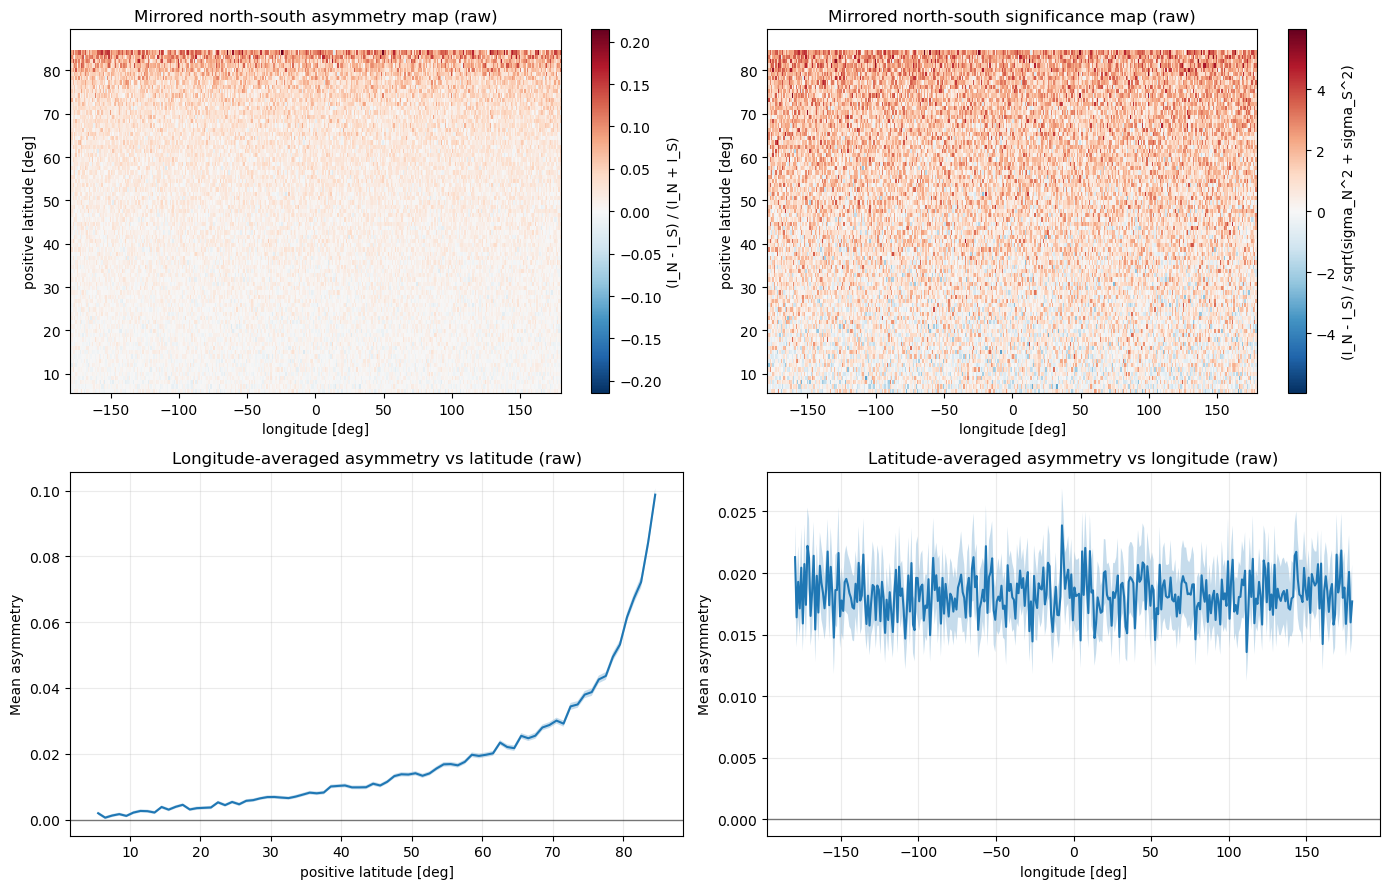

Raw mean mirrored asymmetry:      1.829417e-02
Raw std of mirrored asymmetry:    2.469854e-02
Raw mean |mirrored asymmetry|:    2.063114e-02


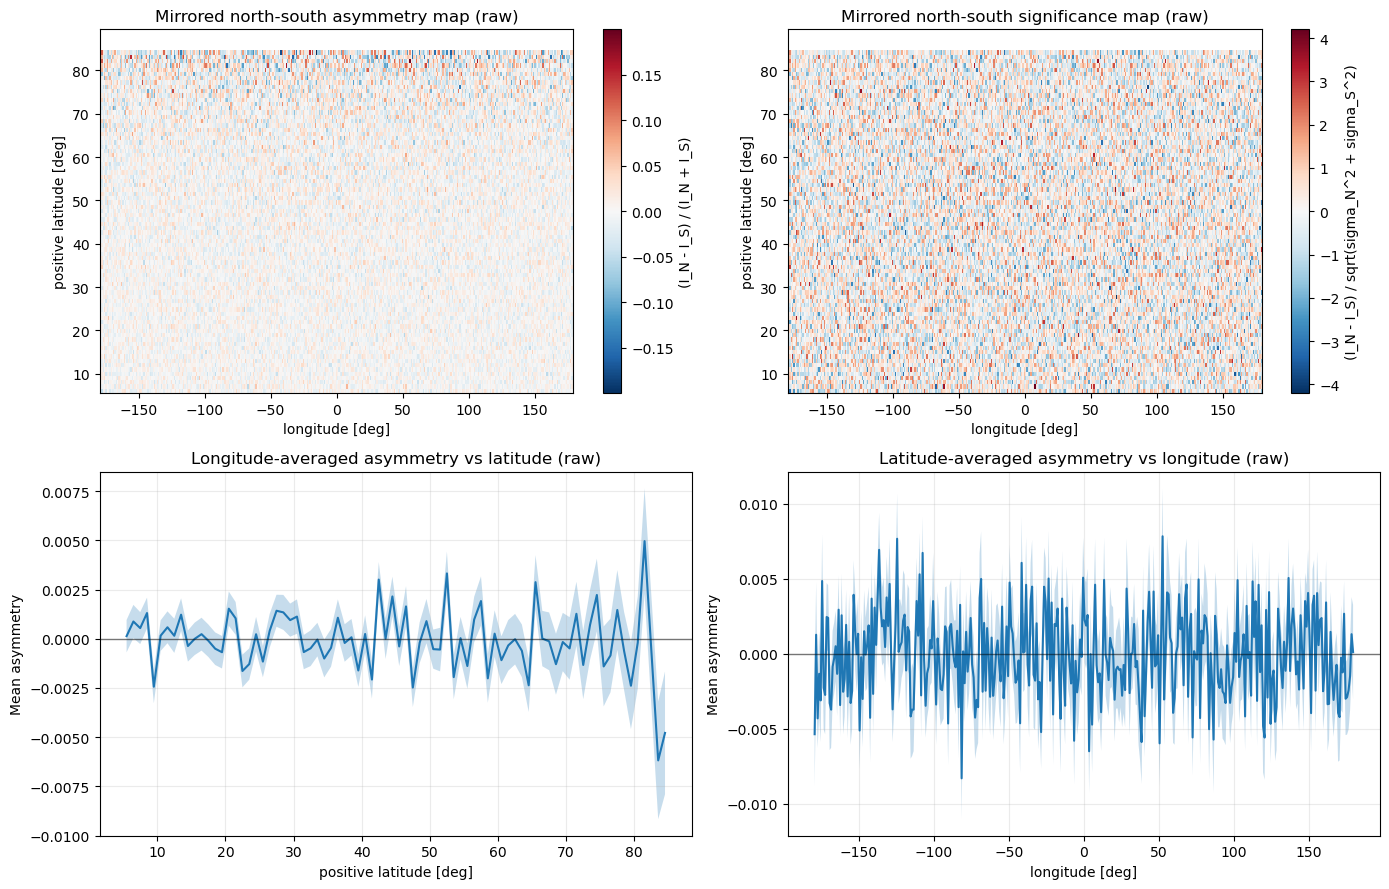

Raw mean mirrored asymmetry:      -8.612522e-05
Raw std of mirrored asymmetry:    2.533975e-02
Raw mean |mirrored asymmetry|:    1.850113e-02


In [4]:
# Mirrored north-south asymmetry diagnostics for the McStas 4PI data
# Assumes Hmc_raw, Hmc_corr, sigma_mcstas_raw, sigma_mcstas_corr, lat_centers, lon_centers,
# and beamstop_mask_deg already exist from the main analysis cell.

def mirrored_asymmetry_diagnostics(I_map, sigma_map):
    lat_pos_mask = lat_centers > beamstop_mask_deg
    lat_pos = lat_centers[lat_pos_mask]

    north_I = I_map[lat_pos_mask, :]
    south_I = I_map[::-1, :][lat_pos_mask, :]
    north_sigma = sigma_map[lat_pos_mask, :]
    south_sigma = sigma_map[::-1, :][lat_pos_mask, :]

    sum_I = north_I + south_I
    diff_I = north_I - south_I
    denom_sigma = np.sqrt(north_sigma**2 + south_sigma**2)

    asym_map = diff_I / np.where(sum_I > 0, sum_I, np.nan)
    pull_map = diff_I / np.maximum(denom_sigma, 1e-30)

    asym_vs_lat = np.nanmean(asym_map, axis=1)
    asym_vs_lon = np.nanmean(asym_map, axis=0)
    asym_lat_sem = np.nanstd(asym_map, axis=1) / np.sqrt(np.maximum(np.sum(np.isfinite(asym_map), axis=1), 1))
    asym_lon_sem = np.nanstd(asym_map, axis=0) / np.sqrt(np.maximum(np.sum(np.isfinite(asym_map), axis=0), 1))

    stats = {
        "mean": float(np.nanmean(asym_map)),
        "std": float(np.nanstd(asym_map)),
        "mean_abs": float(np.nanmean(np.abs(asym_map))),
    }

    return {
        "lat_pos": lat_pos,
        "asym_map": asym_map,
        "pull_map": pull_map,
        "asym_vs_lat": asym_vs_lat,
        "asym_vs_lon": asym_vs_lon,
        "asym_lat_sem": asym_lat_sem,
        "asym_lon_sem": asym_lon_sem,
        "stats": stats,
    }


def plot_mirrored_asymmetry(result, label):
    lat_pos = result["lat_pos"]
    asym_map = result["asym_map"]
    pull_map = result["pull_map"]
    asym_vs_lat = result["asym_vs_lat"]
    asym_vs_lon = result["asym_vs_lon"]
    asym_lat_sem = result["asym_lat_sem"]
    asym_lon_sem = result["asym_lon_sem"]

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))
    asym_absmax = np.nanmax(np.abs(asym_map))
    pull_absmax = min(np.nanmax(np.abs(pull_map)), 8.0)

    im0 = axs[0, 0].imshow(
        asym_map,
        origin="lower",
        extent=[lon_centers[0], lon_centers[-1], lat_pos[0], lat_pos[-1]],
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-asym_absmax,
        vmax=asym_absmax,
    )
    axs[0, 0].set_xlabel("longitude [deg]")
    axs[0, 0].set_ylabel("positive latitude [deg]")
    axs[0, 0].set_title(f"Mirrored north-south asymmetry map ({label})")
    fig.colorbar(im0, ax=axs[0, 0], label="(I_N - I_S) / (I_N + I_S)")

    im1 = axs[0, 1].imshow(
        pull_map,
        origin="lower",
        extent=[lon_centers[0], lon_centers[-1], lat_pos[0], lat_pos[-1]],
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-pull_absmax,
        vmax=pull_absmax,
    )
    axs[0, 1].set_xlabel("longitude [deg]")
    axs[0, 1].set_ylabel("positive latitude [deg]")
    axs[0, 1].set_title(f"Mirrored north-south significance map ({label})")
    fig.colorbar(im1, ax=axs[0, 1], label="(I_N - I_S) / sqrt(sigma_N^2 + sigma_S^2)")

    axs[1, 0].plot(lat_pos, asym_vs_lat, lw=1.5)
    axs[1, 0].fill_between(lat_pos, asym_vs_lat - asym_lat_sem, asym_vs_lat + asym_lat_sem, alpha=0.25)
    axs[1, 0].axhline(0.0, color="k", lw=1.0, alpha=0.5)
    axs[1, 0].set_xlabel("positive latitude [deg]")
    axs[1, 0].set_ylabel("Mean asymmetry")
    axs[1, 0].set_title(f"Longitude-averaged asymmetry vs latitude ({label})")
    axs[1, 0].grid(alpha=0.25)

    axs[1, 1].plot(lon_centers, asym_vs_lon, lw=1.5)
    axs[1, 1].fill_between(lon_centers, asym_vs_lon - asym_lon_sem, asym_vs_lon + asym_lon_sem, alpha=0.25)
    axs[1, 1].axhline(0.0, color="k", lw=1.0, alpha=0.5)
    axs[1, 1].set_xlabel("longitude [deg]")
    axs[1, 1].set_ylabel("Mean asymmetry")
    axs[1, 1].set_title(f"Latitude-averaged asymmetry vs longitude ({label})")
    axs[1, 1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


raw_result = mirrored_asymmetry_diagnostics(Hmc_raw, sigma_mcstas_raw)
plot_mirrored_asymmetry(raw_result, "raw")
print(f"Raw mean mirrored asymmetry:      {raw_result['stats']['mean']:.6e}")
print(f"Raw std of mirrored asymmetry:    {raw_result['stats']['std']:.6e}")
print(f"Raw mean |mirrored asymmetry|:    {raw_result['stats']['mean_abs']:.6e}")


raw_result = mirrored_asymmetry_diagnostics(H_mini_raw, sigma_mini_raw)
plot_mirrored_asymmetry(raw_result, "raw")
print(f"Raw mean mirrored asymmetry:      {raw_result['stats']['mean']:.6e}")
print(f"Raw std of mirrored asymmetry:    {raw_result['stats']['std']:.6e}")
print(f"Raw mean |mirrored asymmetry|:    {raw_result['stats']['mean_abs']:.6e}")





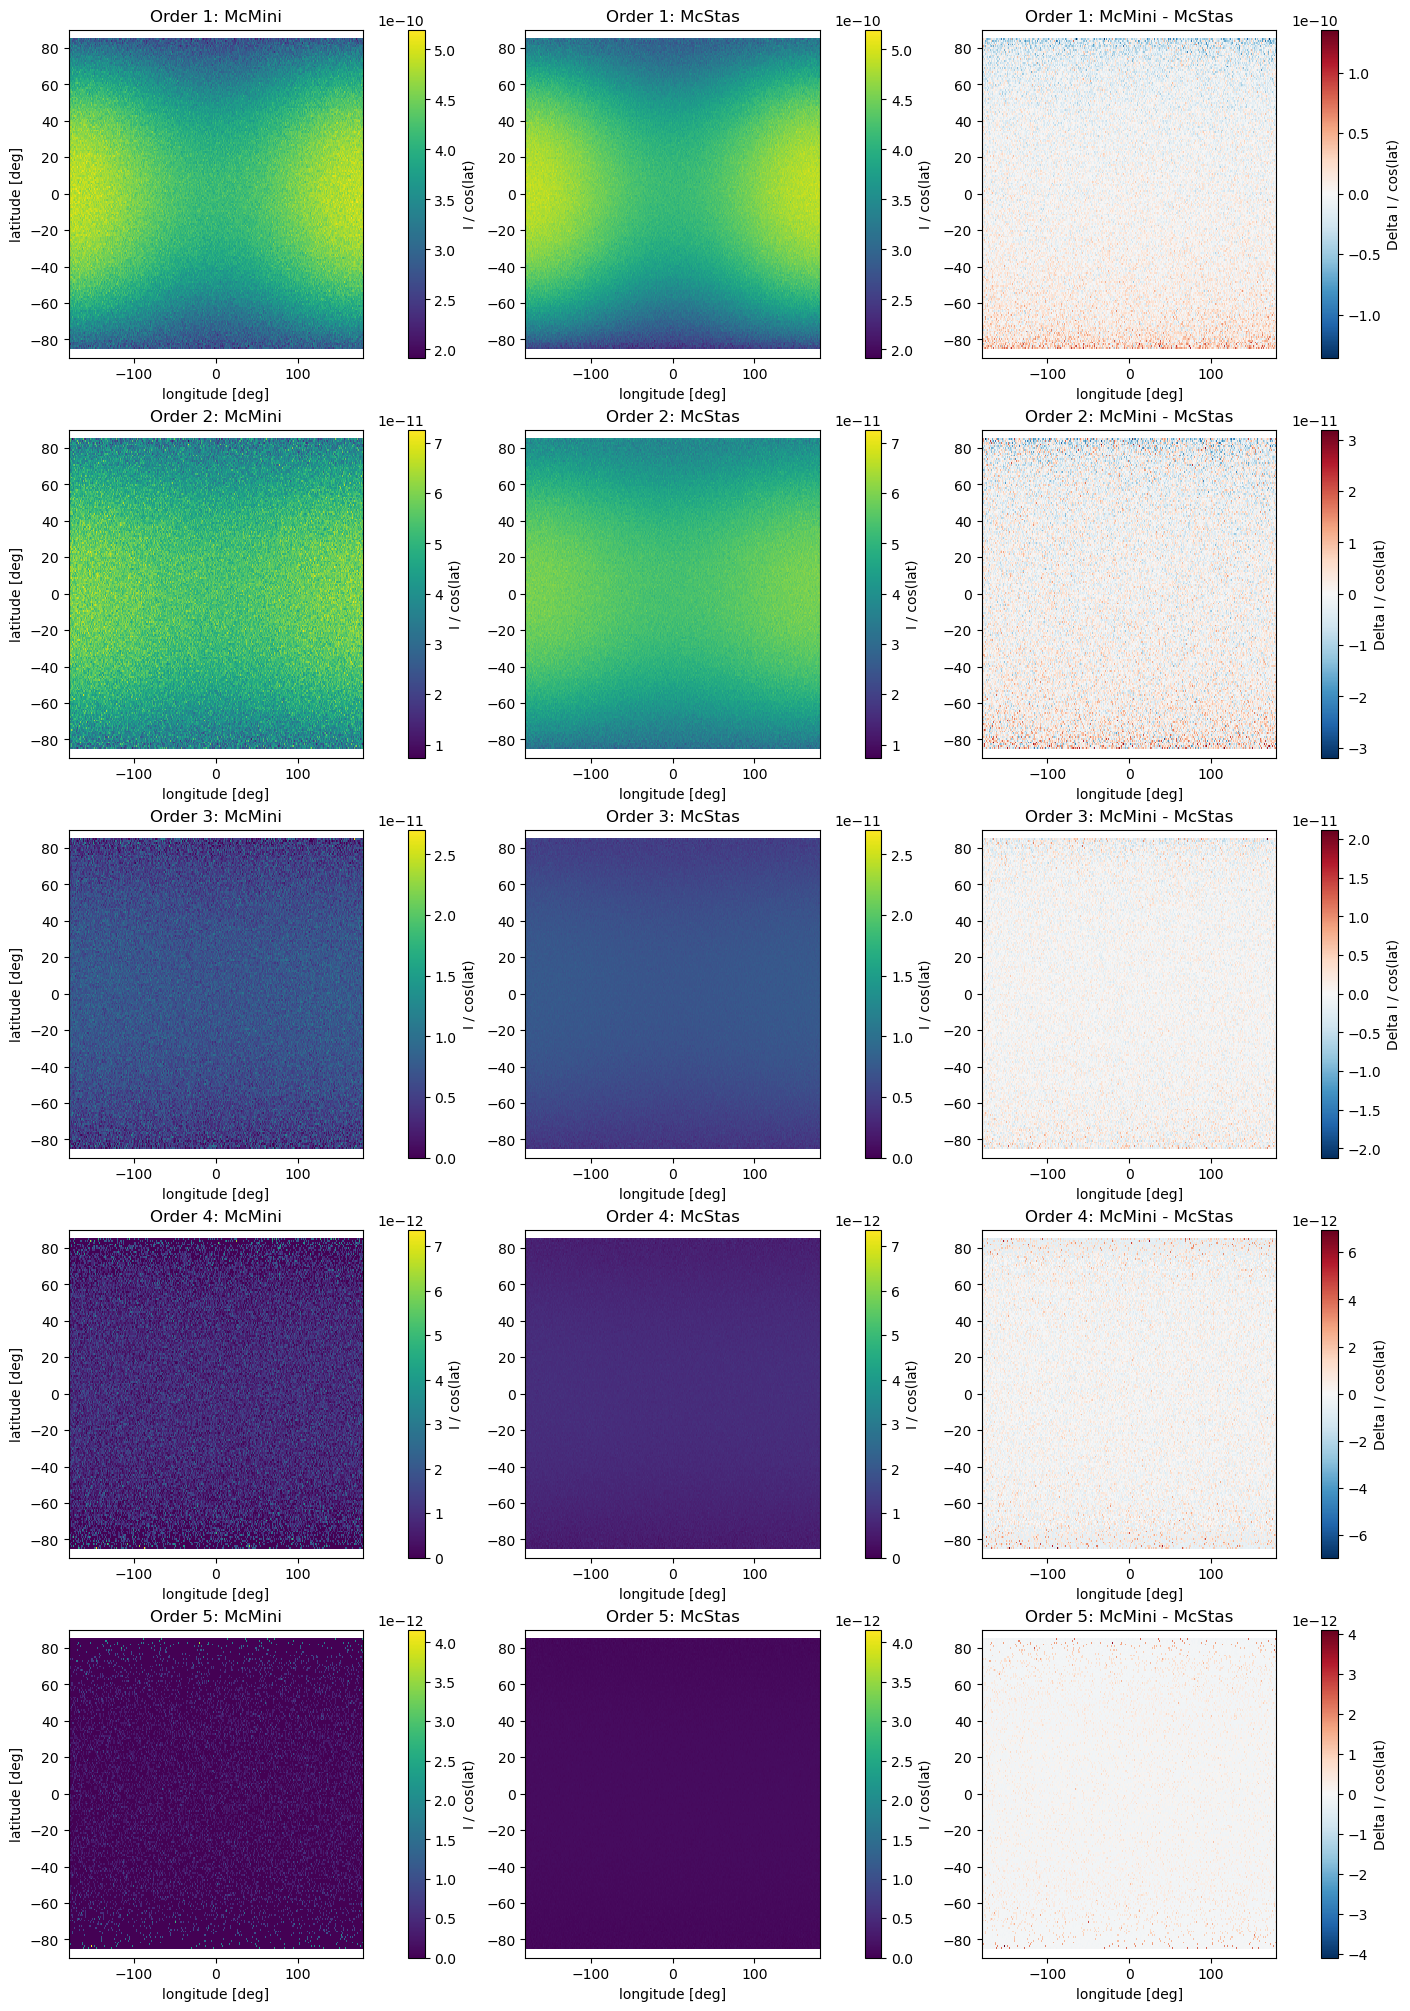

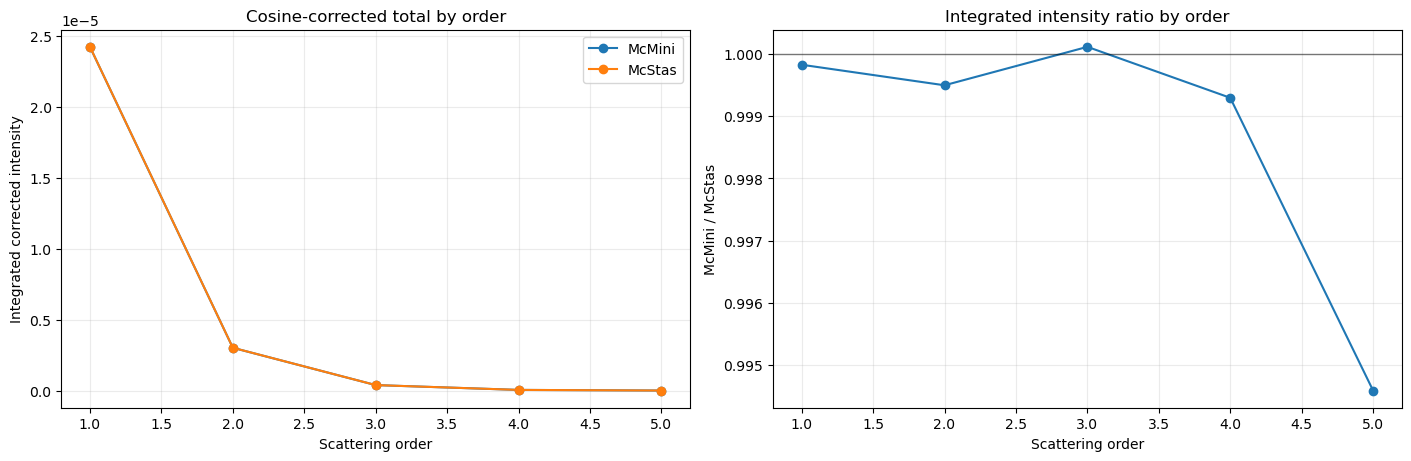

Pole cut: excluding |latitude| > 85.0 deg
order 1: McMini=2.419961e-05, share=87.47%, McStas=2.420378e-05, share=87.47%, ratio=9.998278e-01, RMS=1.729288e-11, mean pull=-1.425874e-02, pull std=1.079463e+00
order 2: McMini=3.016740e-06, share=10.90%, McStas=3.018256e-06, share=10.91%, ratio=9.994977e-01, RMS=5.013830e-12, mean pull=-4.737245e-02, pull std=1.020430e+00
order 3: McMini=3.904320e-07, share=1.41%, McStas=3.903869e-07, share=1.41%, ratio=1.000115e+00, RMS=1.720062e-12, mean pull=-1.816284e-01, pull std=1.290087e+00
order 4: McMini=5.118903e-08, share=0.19%, McStas=5.122508e-08, share=0.19%, ratio=9.992964e-01, RMS=6.133285e-13, mean pull=-1.808580e+00, pull std=4.315684e+00
order 5: McMini=6.732789e-09, share=0.02%, McStas=6.769408e-09, share=0.02%, ratio=9.945905e-01, RMS=2.229384e-13, mean pull=-6.944697e+00, pull std=5.418987e+00


In [11]:
# Cosine-corrected map comparison by scattering order: McMini vs McStas

pole_cut_deg = 5.0
mcmini_dir = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/cyl_r5mmh2cm_mcmini")
mcstas_path = "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/cyl_r5mmh2cm_mcstas"

lat_centers = np.linspace(-89.5, 89.5, 180)
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
extent = [-180, 180, -90, 90]

mcstas_monitors = ms.load_data(mcstas_path)
order_results = []

for order in range(1, 6):
    mcmini_path = mcmini_dir / f"solid_cylinder_scatter_{order}.csv"
    binned_data = np.loadtxt(mcmini_path, delimiter=",", comments="#")
    H_mini = binned_data[:, 2].reshape((180, 360))
    sigma_mini = binned_data[:, 3].reshape((180, 360))

    mcstas_mon = mcstas_monitors[order]
    H_mcstas = np.array(mcstas_mon.Intensity, copy=True)
    sigma_mcstas = np.array(mcstas_mon.Error, copy=True)
    meta = mcstas_mon.metadata
    if H_mcstas.shape == (meta.dimension[0], meta.dimension[1]):
        H_mcstas = H_mcstas.T
        sigma_mcstas = sigma_mcstas.T

    H_mini_corr = H_mini / np.where(cos_correction == 0, np.nan, cos_correction)
    sigma_mini_corr = sigma_mini / np.where(cos_correction == 0, np.nan, cos_correction)
    H_mcstas_corr = H_mcstas / np.where(cos_correction == 0, np.nan, cos_correction)
    sigma_mcstas_corr = sigma_mcstas / np.where(cos_correction == 0, np.nan, cos_correction)

    H_mini_corr = np.where(pole_mask[:, np.newaxis], H_mini_corr, np.nan)
    sigma_mini_corr = np.where(pole_mask[:, np.newaxis], sigma_mini_corr, np.nan)
    H_mcstas_corr = np.where(pole_mask[:, np.newaxis], H_mcstas_corr, np.nan)
    sigma_mcstas_corr = np.where(pole_mask[:, np.newaxis], sigma_mcstas_corr, np.nan)

    diff_corr = H_mini_corr - H_mcstas_corr
    sigma_combined = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
    pull_corr = diff_corr / np.maximum(sigma_combined, 1e-30)

    order_results.append({
        "order": order,
        "mini": H_mini_corr,
        "mcstas": H_mcstas_corr,
        "diff": diff_corr,
        "pull": pull_corr,
        "mini_total": float(np.nansum(H_mini_corr)),
        "mcstas_total": float(np.nansum(H_mcstas_corr)),
        "rms": float(np.sqrt(np.nanmean(diff_corr**2))),
        "mean_pull": float(np.nanmean(pull_corr)),
        "pull_std": float(np.nanstd(pull_corr)),
    })

fig, axs = plt.subplots(5, 3, figsize=(14, 20), constrained_layout=True)

for row, result in enumerate(order_results):
    vmin = min(np.nanmin(result["mini"]), np.nanmin(result["mcstas"]))
    vmax = max(np.nanmax(result["mini"]), np.nanmax(result["mcstas"]))
    diff_absmax = np.nanmax(np.abs(result["diff"]))

    im0 = axs[row, 0].imshow(result["mini"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
    axs[row, 0].set_title(f"Order {result['order']}: McMini")
    axs[row, 0].set_ylabel("latitude [deg]")
    fig.colorbar(im0, ax=axs[row, 0], label="I / cos(lat)")

    im1 = axs[row, 1].imshow(result["mcstas"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
    axs[row, 1].set_title(f"Order {result['order']}: McStas")
    fig.colorbar(im1, ax=axs[row, 1], label="I / cos(lat)")

    im2 = axs[row, 2].imshow(result["diff"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
    axs[row, 2].set_title(f"Order {result['order']}: McMini - McStas")
    fig.colorbar(im2, ax=axs[row, 2], label="Delta I / cos(lat)")

    for col in range(3):
        axs[row, col].set_xlabel("longitude [deg]")

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
orders = [result["order"] for result in order_results]
mini_totals = np.array([result["mini_total"] for result in order_results])
mcstas_totals = np.array([result["mcstas_total"] for result in order_results])
mini_shares = 100.0 * mini_totals / np.sum(mini_totals)
mcstas_shares = 100.0 * mcstas_totals / np.sum(mcstas_totals)

axs[0].plot(orders, mini_totals, marker="o", lw=1.5, label="McMini")
axs[0].plot(orders, mcstas_totals, marker="o", lw=1.5, label="McStas")
axs[0].set_xlabel("Scattering order")
axs[0].set_ylabel("Integrated corrected intensity")
axs[0].set_title("Cosine-corrected total by order")
axs[0].grid(alpha=0.25)
axs[0].legend()

axs[1].plot(orders, mini_totals / mcstas_totals, marker="o", lw=1.5)
axs[1].axhline(1.0, color="k", lw=1.0, alpha=0.5)
axs[1].set_xlabel("Scattering order")
axs[1].set_ylabel("McMini / McStas")
axs[1].set_title("Integrated intensity ratio by order")
axs[1].grid(alpha=0.25)

plt.show()

print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg")
for result in order_results:
    order_idx = result['order'] - 1
    print(
        f"order {result['order']}: "
        f"McMini={result['mini_total']:.6e}, "
        f"share={mini_shares[order_idx]:.2f}%, "
        f"McStas={result['mcstas_total']:.6e}, "
        f"share={mcstas_shares[order_idx]:.2f}%, "
        f"ratio={result['mini_total'] / result['mcstas_total']:.6e}, "
        f"RMS={result['rms']:.6e}, "
        f"mean pull={result['mean_pull']:.6e}, "
        f"pull std={result['pull_std']:.6e}"
    )
